In [24]:
import numpy as np
from matplotlib import pyplot as plt
import cv2 

In [25]:
cap = cv2.VideoCapture('video/mouse_1.avi') 

In [26]:
success, img1 = cap.read()
img = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

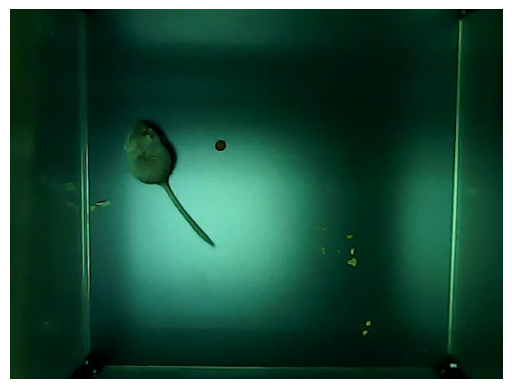

In [27]:
plt.imshow(img)
plt.axis('off')
plt.savefig('mice.png', dpi=300, bbox_inches='tight')

In [28]:
# Инициализируем счетчик кадров, начинаем с 1
i=1

imgs = [] # пустой список Python, который будет использоваться для накопления всех обработанных кадров 
# Каждый кадр будет добавлен в этот список для последующей обработки или анализа

while True: # while True создает цикл, который будет выполняться до тех пор, пока не встретит команду break
    success, img = cap.read() # cap.read() читает один кадр из видеофайла
    # success — True если кадр успешно прочитан, False если достигнут конец видео или произошла ошибка

    # Проверка валидности прочитанного кадра
    if not success or img is None or img.size == 0: # not success — если чтение не удалось (конец видео или ошибка)
        # img is None — если кадр не существует, img.size == 0 — если массив пустой 
        print(f"Конец видео или ошибка чтения на кадре {i}")
        break
    
    # Преобразование кадра в оттенки серого
    # Для уменьшения объема данных, упрощения последующей обработки (детекции движения), повышения скорости обработки
    img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    imgs.append(img_grey) # Метод append() добавляет преобразованный кадр img_grey в конец списка imgs

    # Увеличивает переменную i на 1
    i += 1 # Это позволяет отслеживать номер следующего кадра и выводить корректную информацию при возникновении ошибки

cap.release() # cap.release() закрывает видеофайл и освобождает все системные ресурсы, связанные с объектом VideoCapture
# Это для предотвращения утечек памяти и корректного завершения работы с файлом
print(f"Загружено {len(imgs)} кадров")

Конец видео или ошибка чтения на кадре 6076
Загружено 6075 кадров


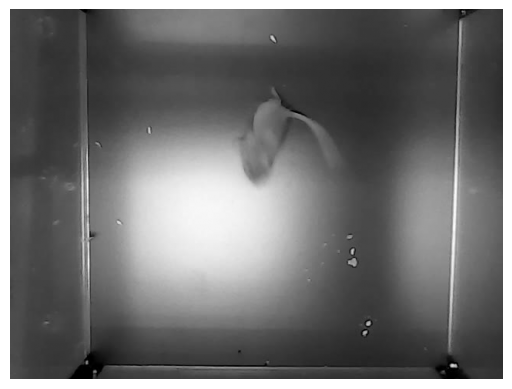

In [32]:
plt.imshow(imgs[2000], cmap='gray') # то есть 3001-й кадр, так как индексация в Python начинается с 0
# cmap='gray' — параметр цветовой карты (colormap), который указывает, что изображение следует отображать в оттенках серого
# Поскольку imgs содержит изображения в оттенках серого (одноканальные), параметр cmap='gray' обязателен 
# Без него Matplotlib может отобразить изображение в псевдоцветах (например, в фиолетово-желтой гамме по умолчанию)

plt.axis('off')  # Отключаем оси

plt.savefig('MiceGray.png', dpi=300, bbox_inches='tight')
plt.show()